In [11]:
## Based on
#  - https://realpython.com/linear-regression-in-python/
#  - https://stackabuse.com/linear-regression-in-python-with-scikit-learn/

In [12]:
import pandas as pd
import numpy as np

In [13]:
# Local data cache
datafile = "../../data/CLEAN-DataSample-WeightHeight.csv"

In [14]:
# Read data from local file
data = pd.read_csv(datafile)
data.set_index('S.No.', inplace=True)
data.head()

,Height (cm),Weight (kg),BMI (numeric),"BMI Category = C1, C2, C3, C4"
S.No.,,,,
1,164.0,74.5,NaN,NaN
2,151.0,75.2,NaN,NaN
3,168.0,67.8,NaN,NaN
4,168.0,76.4,NaN,NaN
5,170.0,70.0,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 1 to 30
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Height (cm)                    29 non-null     float64
 1   Weight (kg)                    29 non-null     float64
 2   BMI (numeric)                  0 non-null      float64
 3   BMI Category = C1, C2, C3, C4  0 non-null      float64
dtypes: float64(4)
memory usage: 1.1 KB


In [16]:
# Clean data by removing row w NaN value
data = data.dropna(subset=['Height (cm)', 'Weight (kg)'])

In [17]:
print(data)

       Height (cm)  Weight (kg)  BMI (numeric)  BMI Category = C1, C2, C3, C4
S.No.                                                                        
1            164.0       74.500            NaN                            NaN
2            151.0       75.200            NaN                            NaN
3            168.0       67.800            NaN                            NaN
4            168.0       76.400            NaN                            NaN
5            170.0       70.000            NaN                            NaN
6            180.0       77.000            NaN                            NaN
7            150.0       53.000            NaN                            NaN
8            173.0       64.500            NaN                            NaN
9            193.0       88.000            NaN                            NaN
10           190.0       81.500            NaN                            NaN
11           193.0      102.000            NaN                  

In [18]:
# Seeing visually if there is a relationship between cases and deaths
import matplotlib.pyplot as plt
%matplotlib inline

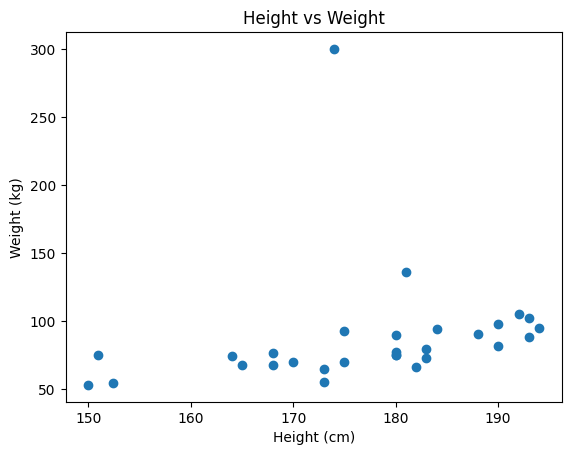

In [19]:
data.plot(x='Height (cm)', y='Weight (kg)', style='o', legend=False)
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

In [21]:
# Imports for classification
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Get the data of interest
x = data ['Height (cm)']
y = data ['Weight (kg)']

In [ ]:
# Type and shape changes
x, y = np.array(x), np.array(y)
print(x)
print(y)

[164.  151.  168.  168.  170.  180.  150.  173.  193.  190.  193.  181.
 152.4 188.  182.  175.  180.  183.  165.  180.  194.  174.  175.  192.
 184.  183.  173.  190.  180. ]
[ 74.5    75.2    67.8    76.4    70.     77.     53.     64.5    88.
  81.5   102.    136.078  54.43   90.7    66.     70.     75.     72.5
  68.     74.8    95.    300.     93.    105.     94.     79.4    55.
  98.     90.   ]


In [ ]:
x = x.reshape(-1,1)

In [ ]:
# Get a subset for taining and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
print (x_train.size, x_test.size, y_train.size, y_test.size)

23 6 23 6


In [ ]:
# Train a linear regression mode
model = LinearRegression().fit(x_train, y_train)

In [ ]:
# Model information
print (' Model details:')
print (' -  intercept : ', model.intercept_)
print (' -  coeff : ', model.coef_)

 Model details:
 -  intercept :  -30.65326358105149
 -  coeff :  [0.66523949]


In [ ]:
# Predicted values for train and test
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

In [ ]:
# Define a function to predict error statistics
def print_stats(y_actual, y_pred):
    print('Mean Absolute Error:', metrics.mean_absolute_error(y_actual, y_pred))
    print('Mean Squared Error:', metrics.mean_squared_error(y_actual, y_pred))
    print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_actual, y_pred)))

In [ ]:
# Print for training data
print_stats(y_train, y_pred_train)

Mean Absolute Error: 20.62775609155806
Mean Squared Error: 2192.8549358154924
Root Mean Squared Error: 46.82792901480368


In [ ]:
# Print for test data
print_stats(y_test, y_pred_test)

Mean Absolute Error: 14.392948494260487
Mean Squared Error: 424.6068438186428
Root Mean Squared Error: 20.60599048380453


In [ ]:
import matplotlib.pyplot as plt

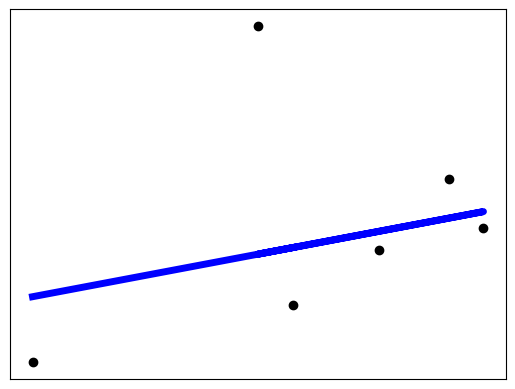

In [ ]:
# Visually showing the results
plt.scatter(x_test, y_test, color='black')
plt.plot(x_test, y_pred_test, color='blue', linewidth=5)
plt.xticks(())
plt.yticks(())
plt.show()

## Now we can try other regions or classification

In [ ]:
# Now classification for county
# Finding the number of cases in a state
condition = (data['Height (cm)'] == 50)
data_sc = data[condition]

NameError: name 'data' is not defined

In [ ]:
data_sc.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6280 entries, 637 to 398070
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    6280 non-null   datetime64[ns]
 1   county  6280 non-null   object        
 2   state   6280 non-null   object        
 3   fips    6280 non-null   float64       
 4   cases   6280 non-null   int64         
 5   deaths  6280 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 343.4+ KB


In [ ]:
# See a sample
data_sc.head()

,date,county,state,fips,cases,deaths
637,2020-03-06,Charleston,South Carolina,45019.0,1,0
638,2020-03-06,Kershaw,South Carolina,45055.0,1,0
729,2020-03-07,Charleston,South Carolina,45019.0,1,0
730,2020-03-07,Kershaw,South Carolina,45055.0,1,0
838,2020-03-08,Charleston,South Carolina,45019.0,1,0
